# Differential AMF profiles from OMI look-up table

In [1]:
import os
import xarray as xr
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib.pyplot as plt

In [3]:
# Load the AMF look-up table and preview it
ds = xr.load_dataset("/orcd/data/dvaron/001/kgauld/AMF/differential_amf.nc")
ds['dalb']

<xarray.DataArray 'dalb' (dalb: 8)> Size: 32B
array([0.  , 0.02, 0.05, 0.1 , 0.2 , 0.4 , 0.8 , 1.  ], dtype=float32)
Coordinates:
  * dalb     (dalb) float32 32B 0.0 0.02 0.05 0.1 0.2 0.4 0.8 1.0

In [3]:
# Check the shape of the AMF array
ds["damf"].data.shape

(6, 8, 5, 6, 9, 35)

## Plot the scattering AMF for a test case

In [4]:
# Config
albedo = ds["dalb"].data
sza = 59.161766#28.560043 # 28.561049 za= vza= phi=
vza = 7.8966665#8.993752 # 8.998423
phi = 52.84556#80.694786 # 80.593575
surface_altitude_m = 1400 #671
deg_to_rad = np.pi/180
AMF_G = 1/np.cos(sza*deg_to_rad) + 1/np.cos(vza*deg_to_rad)
print(f"AMF_G = {AMF_G}")

AMF_G = 2.9603515097559088


In [5]:
# Convert altitude to pressure via barometric formula with H=8km
p0 = 1013
H = 8000
p = lambda z: p0 * np.exp(-z/H)
surface_pressure = p(surface_altitude_m)
pressure_at_500m = p(surface_altitude_m+500)
print(f"Pressure at 500m above ground = {pressure_at_500m} hPa")

Pressure at 500m above ground = 798.8486505638307 hPa


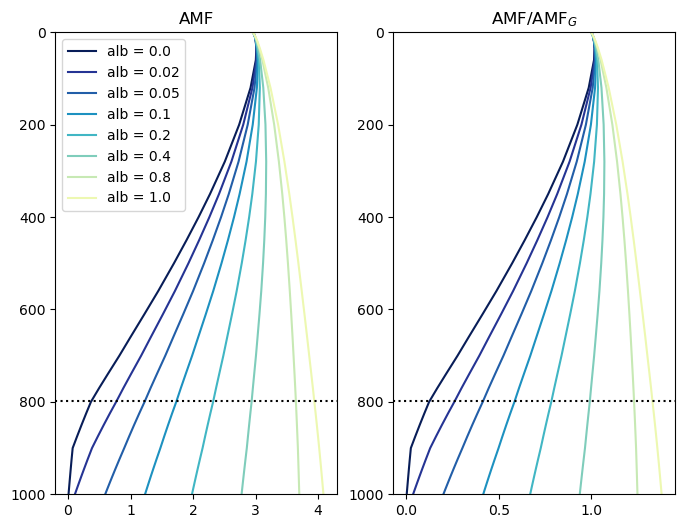

In [6]:
# Create AMF plot
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(8,6))

# Define plor colors
colors = [[237,248,177],
          [199,233,180],
          [127,205,187],
          [65,182,196],
          [29,145,192],
          [34,94,168],
          [37,52,148],
          [8,29,88]]
colors.reverse()

# Query look-up table
verbose = False
do_interpolate = True
for k in range(len(albedo)):
    if do_interpolate:
        amf_profile = ds["damf"].interp(dspres=surface_pressure, dalb=albedo[k], dphi=phi, dvza=vza, dsza=sza).data
    else:
        idx_alb = np.argmin(np.abs(albedo[k]-ds["dalb"].data))
        idx_sza = np.argmin(np.abs(sza-ds["dsza"].data))
        idx_vza = np.argmin(np.abs(vza-ds["dvza"].data))
        idx_phi = np.argmin(np.abs(phi-ds["dphi"].data))
        idx_spr = np.argmin(np.abs(surface_pressure-ds["dspres"].data))
        if verbose:
            print(f"Matching indexes: alb{idx_alb} sza{idx_sza} vza{idx_vza} phi{idx_phi} spr{idx_spr}")
        amf_profile = ds["damf"].data[idx_spr, idx_alb, idx_phi, idx_vza, idx_sza, :]

# Plot

    ax.plot(amf_profile, ds["dpres"].data, c=np.array(colors[k])/255, 
            label=f"alb = {str(np.round(albedo[k],2))}")
    ax2.plot(amf_profile/AMF_G, ds["dpres"].data, c=np.array(colors[k])/255, 
            label=f"alb = {str(np.round(albedo[k],2))}")

ax.axhline(y = pressure_at_500m, color = 'k', linestyle = ':')
ax.set_ylim(0,1000)
ax2.axhline(y = pressure_at_500m, color = 'k', linestyle = ':')
ax2.set_ylim(0,1000)
ax.set_title("AMF")
ax2.set_title("AMF/AMF$_G$")
ax.legend();
ax.invert_yaxis()
ax2.invert_yaxis()

In [7]:
from amf_compute import get_mcd43_albedo_for_footprint

In [12]:
# Example: one OMI pixel footprint
# Replace these with your actual OMI pixel polygon vertices
footprint_lons = [-113.47083567022987, -113.47083567022987, 
                  -112.10061409154204, -112.10061409154204]  # arbitrary example
footprint_lats = [39.28035559455419,   40.30083719767667,   
                  39.28035559455419,   40.30083719767667]

# Rough center (for search only)
center_lon = np.mean(footprint_lons)
center_lat = np.mean(footprint_lats)

DATE = "2024-08-04"

mean_alb, meta, n_valid, fname = get_mcd43_albedo_for_footprint(
    center_lat=center_lat,
    center_lon=center_lon,
    date_str=DATE,
    footprint_lons=footprint_lons,
    footprint_lats=footprint_lats,
    band="Band1",   # ignore wavelength/LUT nuance for now
    sky="BSA",      # white-sky albedo for Lambertian AMF LUT
    out_dir="modis_brdf",
)

print(f"Granule file      : {fname}")
print(f"Center            : lat={center_lat:.4f}, lon={center_lon:.4f}")
print(f"Date              : {DATE}")
print(f"Field             : {meta.get('long_name', 'Albedo_WSA_Band1')}")
print(f"Units             : {meta.get('units', '1')}")
print(f"Mean albedo       : {mean_alb!r}")
print(f"# valid MCD43 px  : {n_valid}")

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

Granule file      : MCD43A3.A2024210.h09v05.061.2024222000620.hdf
Center            : lat=39.7906, lon=-112.7857
Date              : 2024-08-04
Field             : Albedo_BSA_Band1
Units             : reflectance, no units
Mean albedo       : 0.16419561543731445
# valid MCD43 px  : 21895
